# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
from sklearn import preprocessing
import statsmodels.api as sm
import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [134]:
dir("/Users/ljunodrstat/CStat2026_project/")
os.listdir()

['CP_project_midterm_presentation.pptx',
 '.DS_Store',
 'report.md',
 'project_STUDENTID_processed.ipynb.zip',
 'README.md',
 'project_STUDENTID.ipynb',
 '.ipynb_checkpoints',
 '.jupyter',
 '.git',
 'Data',
 'project_STUDENTID_processed.ipynb']

In [135]:
train = pd.read_csv('Data/train.csv', keep_default_na=False, na_values=[''])
test = pd.read_csv('Data/test.csv', keep_default_na=False, na_values=[''])

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000


# Cleaning the data
NA Values : Is there any NAs values in the variables of intersts for the project ? If any, how to replace them
Missing values ? 

In [73]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
features_dt = pd.DataFrame(train[features])
features_dt.head()

,OverallQual,ExterQual,BsmtQual,KitchenQual,FireplaceQu,CentralAir,LotShape,LandSlope,MoSold,YrSold
0,7,Gd,Gd,Gd,NA,Y,Reg,Gtl,2,2008
1,6,TA,Gd,TA,TA,Y,Reg,Gtl,5,2007
2,7,Gd,Gd,Gd,TA,Y,IR1,Gtl,9,2008
3,7,TA,TA,Gd,Gd,Y,IR1,Gtl,2,2006
4,8,Gd,Gd,Gd,TA,Y,IR1,Gtl,12,2008


In [19]:
na_dt = features_dt[features_dt.isna().any(axis=1)]
na_dt.shape

(699, 10)

In [86]:
features_dt['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', 'NA', 'Fa'], dtype=object)

In [71]:
#features_dt_copy = features_dt.copy()
#for col in features_dt_copy.columns:
#    features_dt_copy[col] = features_dt_copy[col].fillna('NA')
#    sns.histplot(features_dt_copy[col], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)
#    plt.title(f'{col} Distribution')
#    plt.xlabel(col)
#    plt.ylabel('Frequency')
#    plt.xticks(rotation=45)
#    plt.show()


We observe in BsmtQual and FireplaceQu a high number of values which correspond to None according to the description file. 
We replace them with None for clarity purpose.

In [74]:
train['BsmtQual'] = train['BsmtQual'].fillna('No_Basement')
train['FireplaceQu'] = train['FireplaceQu'].fillna('No_Fireplace')
train['KitchenQual'] = train['KitchenQual'].fillna('No_Kitchen')
train['KitchenQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

# Ordinales Values
the variable OverallQual, ExterQual, BsmtQual, KitchenQual, FireplaceQu, Lotshape and LotShape are ordinal value, according to the description file. Outside of OverallQual, which is numeroc of type string, we need to correct them by adding a rank, by using a dictionnary. 
features.unique()

In [52]:
features


['OverallQual',
 'ExterQual',
 'BsmtQual',
 'KitchenQual',
 'FireplaceQu',
 'CentralAir',
 'LotShape',
 'LandSlope',
 'MoSold',
 'YrSold']

In [76]:
qual_dict = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0,
    'No_basement': 0,
    'No_Fireplace': 0,
    'No_Kitchen': 0
}
slope_dict = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1,   
    'NA': 0}
lotshape_dict = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1,
    'NA': 0}

train['ExterQual'] = train['ExterQual'].map(qual_dict)
train['BsmtQual'] = train['BsmtQual'].map(qual_dict)
train['KitchenQual'] = train['KitchenQual'].map(qual_dict)
train['FireplaceQu'] = train['FireplaceQu'].map(qual_dict)

train['LotShape'] = train['LotShape'].map(lotshape_dict)
train['LandSlope'] = train['LandSlope'].map(slope_dict)

In [77]:
train['BsmtQual']

0       4
1       4
2       4
3       3
4       4
       ..
1455    4
1456    4
1457    3
1458    3
1459    3
Name: BsmtQual, Length: 1460, dtype: int64

<Axes: xlabel='LandSlope', ylabel='Count'>

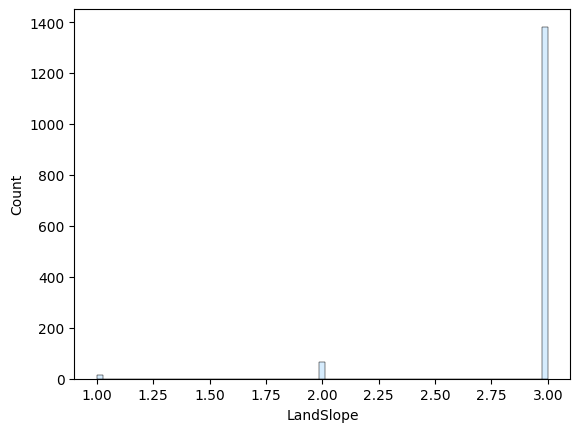

In [83]:
sns.histplot(train['LandSlope'], color='#c9e6fd', edgecolor='black', linewidth=0.35)

In [84]:
features_dt_copy = train[features].copy()
features_dt_copy.head

<bound method NDFrame.head of       OverallQual  ExterQual  BsmtQual  KitchenQual  FireplaceQu CentralAir  \
0               7          4         4            4            0          Y   
1               6          3         4            3            3          Y   
2               7          4         4            4            3          Y   
3               7          3         3            4            4          Y   
4               8          4         4            4            3          Y   
...           ...        ...       ...          ...          ...        ...   
1455            6          3         4            3            3          Y   
1456            6          3         4            3            3          Y   
1457            7          5         3            4            4          Y   
1458            5          3         3            4            0          Y   
1459            5          4         3            3            0          Y   

      LotShape  LandS

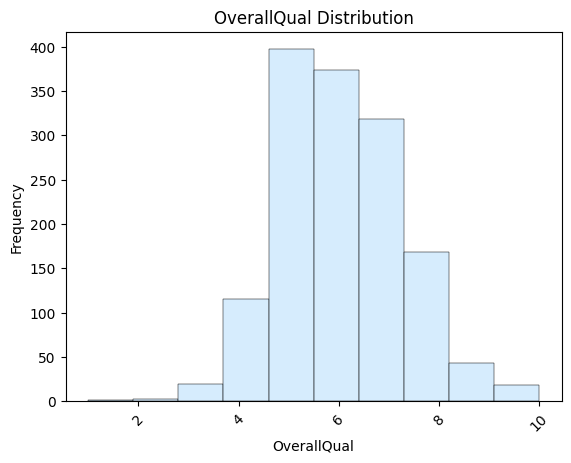

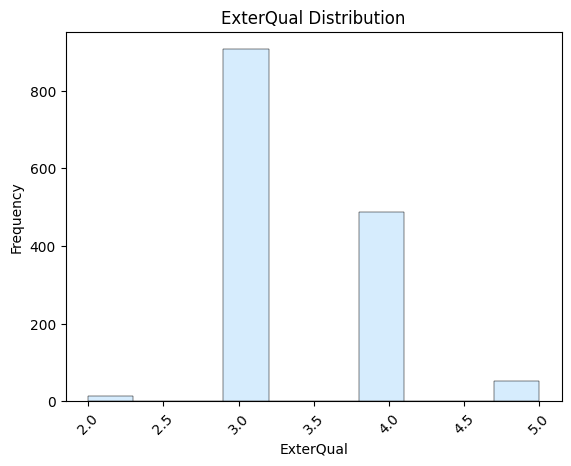

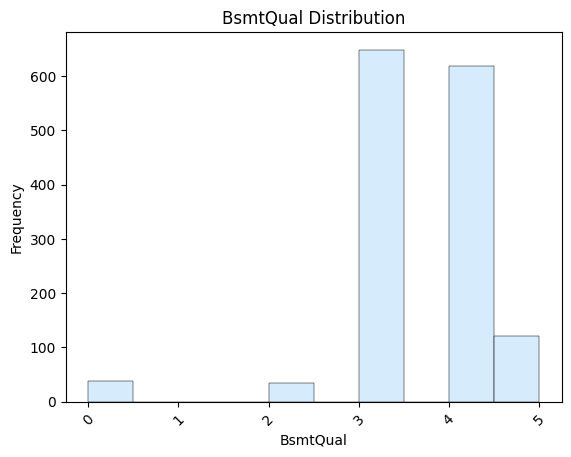

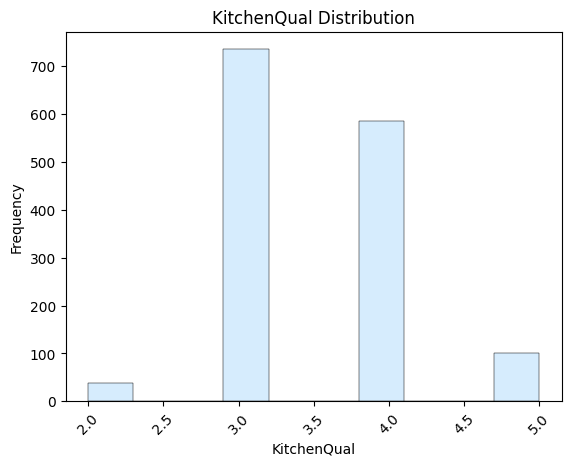

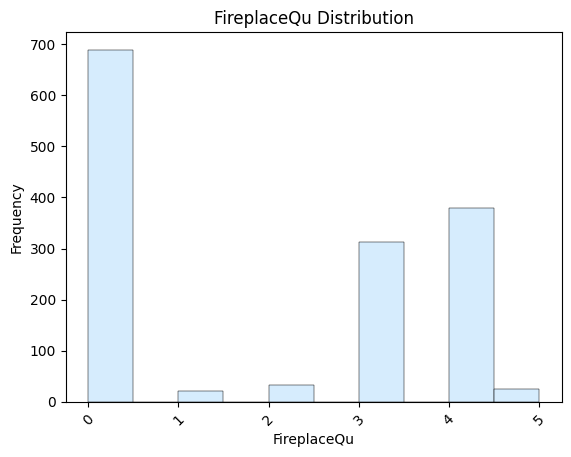

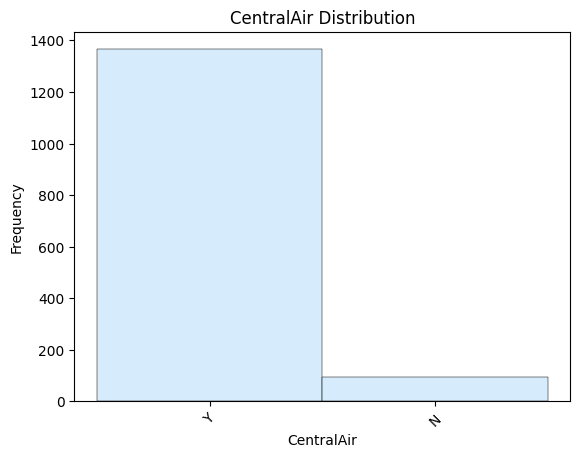

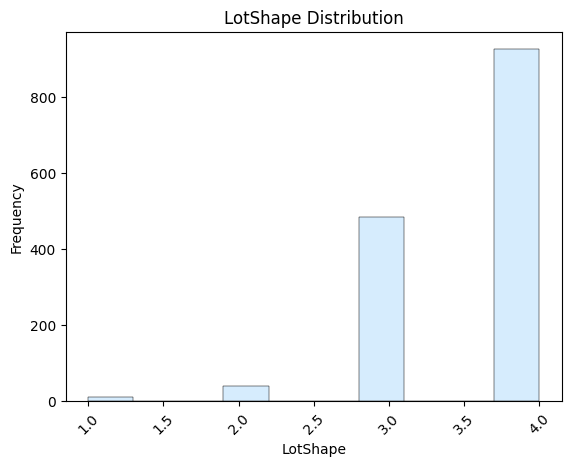

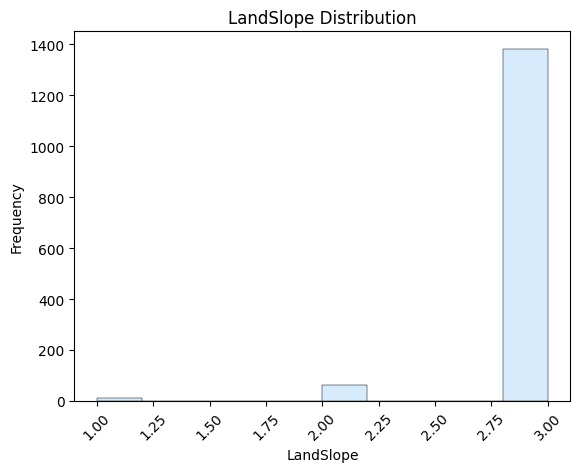

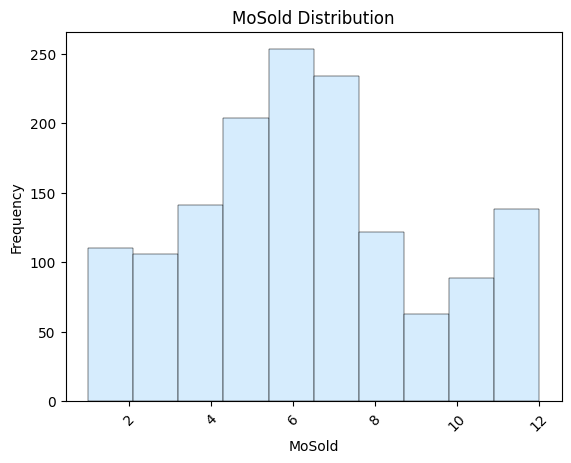

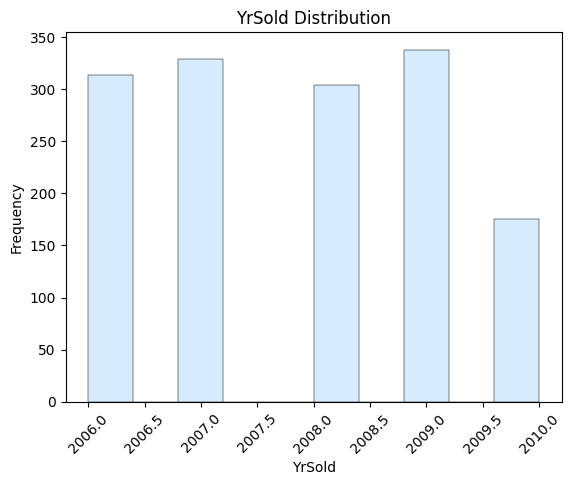

In [85]:

for col in features_dt_copy.columns:
    features_dt_copy[col] = features_dt_copy[col].fillna('NA')
    sns.histplot(features_dt_copy[col], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

na_dt.head()

In [11]:
missing_dt=features_dt[features_dt.isnull().any(axis=1)]

In [12]:
missing_dt.shape

(0, 10)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


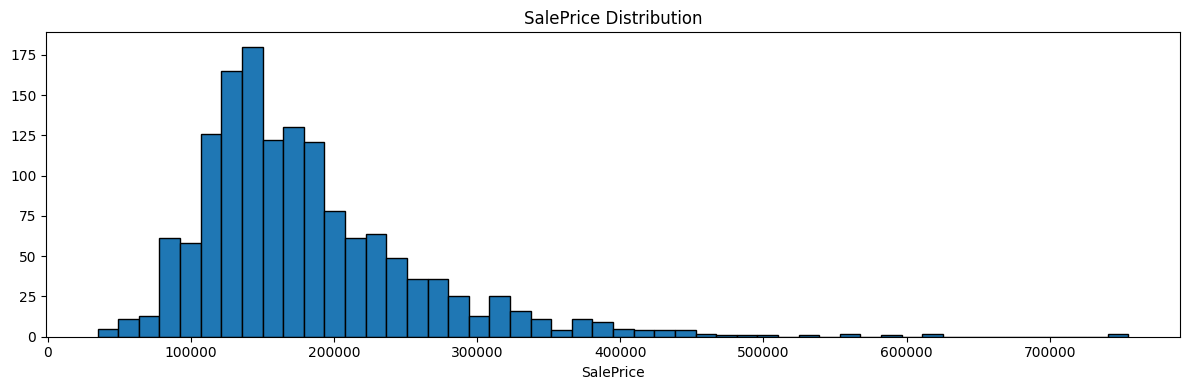

Skewness: 1.883


In [90]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

IndexError: index 0 is out of bounds for axis 0 with size 0

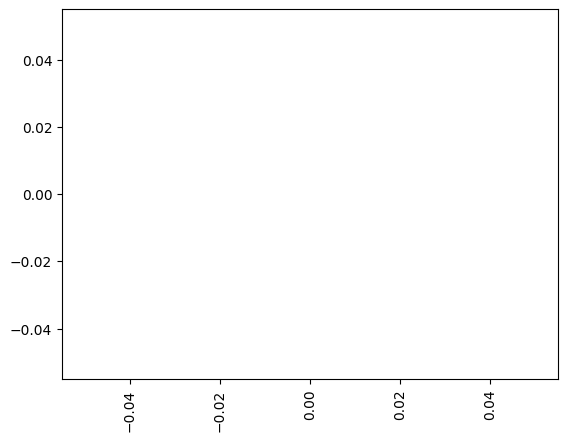

In [91]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_null = train[features]
missing_pd = train_null.isnull()
missing = missing_pd.sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.title('Nombre de valeurs manquantes par variable')
plt.ylabel('Nombre de valeurs manquantes')
plt.xlabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [92]:
train_null = train[features]
missing_pd = train_null.isnull()
missing_pd = train_null[train_null['BsmtQual'].isna()]
missing_pd.shape
train_null.sort_values(by ='BsmtQual', ascending=False)
#missing = missing_pd.sum()
#missing = missing[missing > 0]

,OverallQual,ExterQual,BsmtQual,KitchenQual,FireplaceQu,CentralAir,LotShape,LandSlope,MoSold,YrSold
1193,6,3,5,3,0,Y,4,3,6,2009
81,6,3,5,3,0,Y,4,3,3,2006
697,5,3,5,3,0,Y,3,3,9,2006
700,8,4,5,4,4,Y,4,3,5,2006
702,8,5,5,5,4,Y,3,3,7,2006
...,...,...,...,...,...,...,...,...,...,...
1048,5,3,0,3,3,Y,4,3,11,2009
1049,4,3,0,4,0,Y,4,3,4,2010
1216,6,3,0,3,0,Y,4,3,4,2010
984,5,3,0,4,0,Y,4,3,8,2009


<Axes: xlabel='BsmtQual', ylabel='Count'>

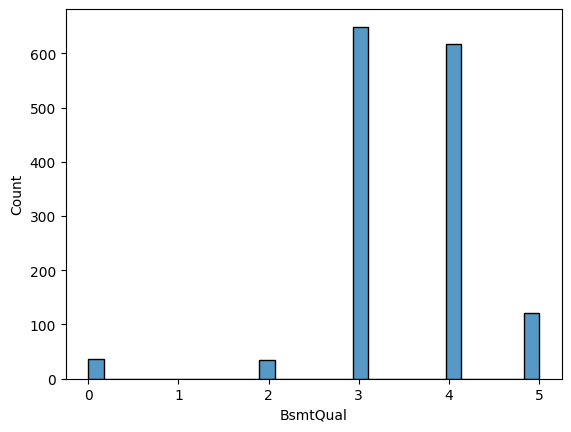

In [93]:
sns.histplot(train_null['BsmtQual'], kde=False)

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

---
## Part 1: Classical Statistical Inference



Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

Skewness after log transformation: 0.121


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_1817/3186336656.py:14: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x, p, 'r', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_1817/3186336656.py:14: SyntaxWarning: invalid escape sequence '\s'
  axes[i].plot(x, p, 'r', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')


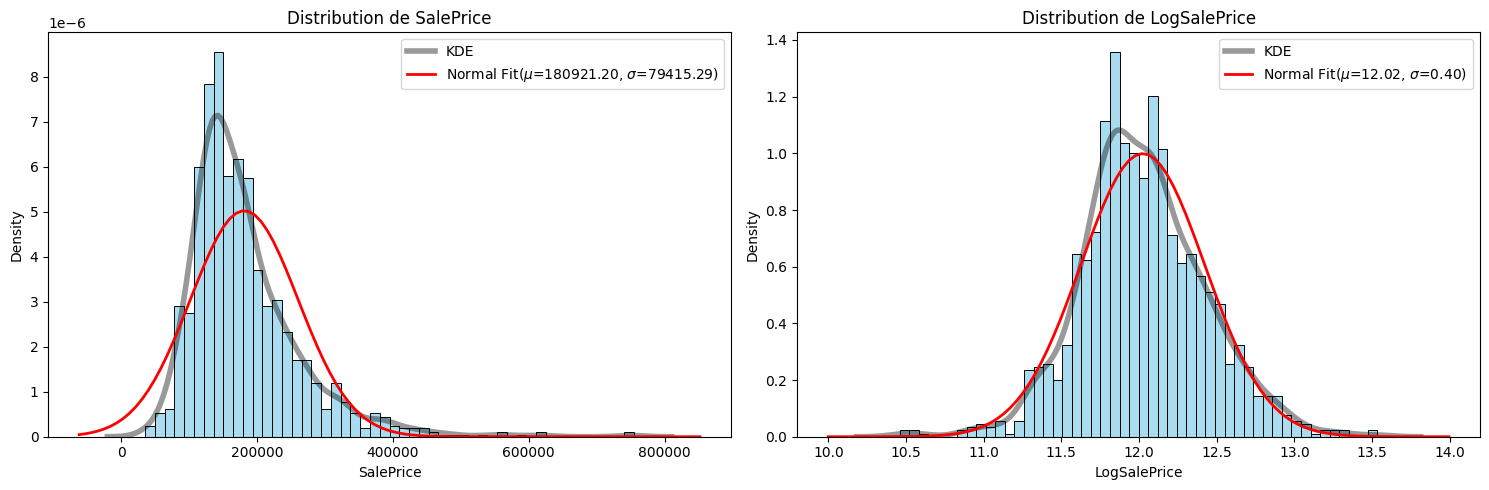

In [136]:

train['LogSalePrice'] = np.log(train['SalePrice'])

print(f'Skewness after log transformation: {train["LogSalePrice"].skew():.3f}')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = ['SalePrice', 'LogSalePrice']
for i, col in enumerate(cols):
    sns.histplot(train[col], bins=50, ax=axes[i], 
                stat='density', color='skyblue', alpha=0.7)
    sns.kdeplot(train[col], ax=axes[i], linewidth=4, color='black', label='KDE', alpha=0.4)
    mu, std = stats.norm.fit(train[col])
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'r', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].legend()
plt.tight_layout()
plt.show()


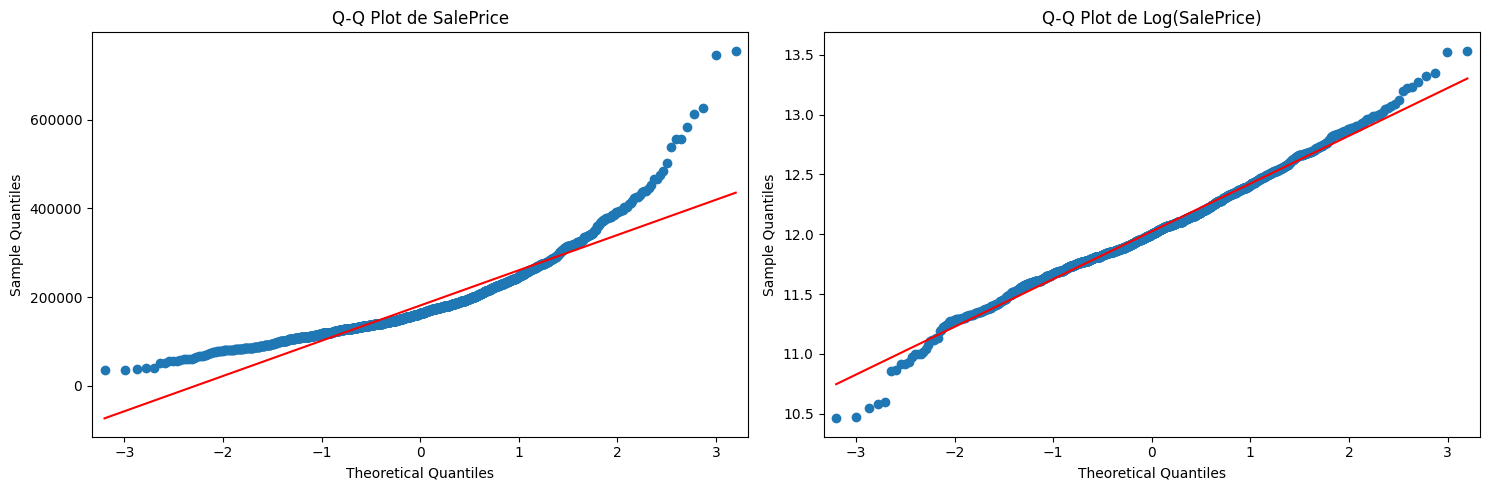

In [95]:
#Q-Q plot for SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sm.qqplot(train['SalePrice'], line='s', ax=axes[0])
sm.qqplot(train['LogSalePrice'], line='s', ax=axes[1])
axes[0].set_title('Q-Q Plot de SalePrice')
axes[1].set_title('Q-Q Plot de Log(SalePrice)')
axes[0].set_title('Q-Q Plot de SalePrice')
axes[1].set_title('Q-Q Plot de Log(SalePrice)')
plt.tight_layout()
plt.show()


In [96]:
#Shapiro-Wilk test for SalePrice
shapiro_test = stats.shapiro(train['LogSalePrice'])
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic: 0.991, p-value: 1.149e-07


Le résultat des QQplots et du test de shapiro (H0 distribution normale) avec W = 0.991 avec une p-value < 0.05 confirme que la transformation de SalePrice en log donne une distribution normale. 

Valeurs nulles

In [97]:

#sns.histplot(train_null['OverallQual'], kde=False)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   object 
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   int64  
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   int64  
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Analyse de TotalBsmtSF

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


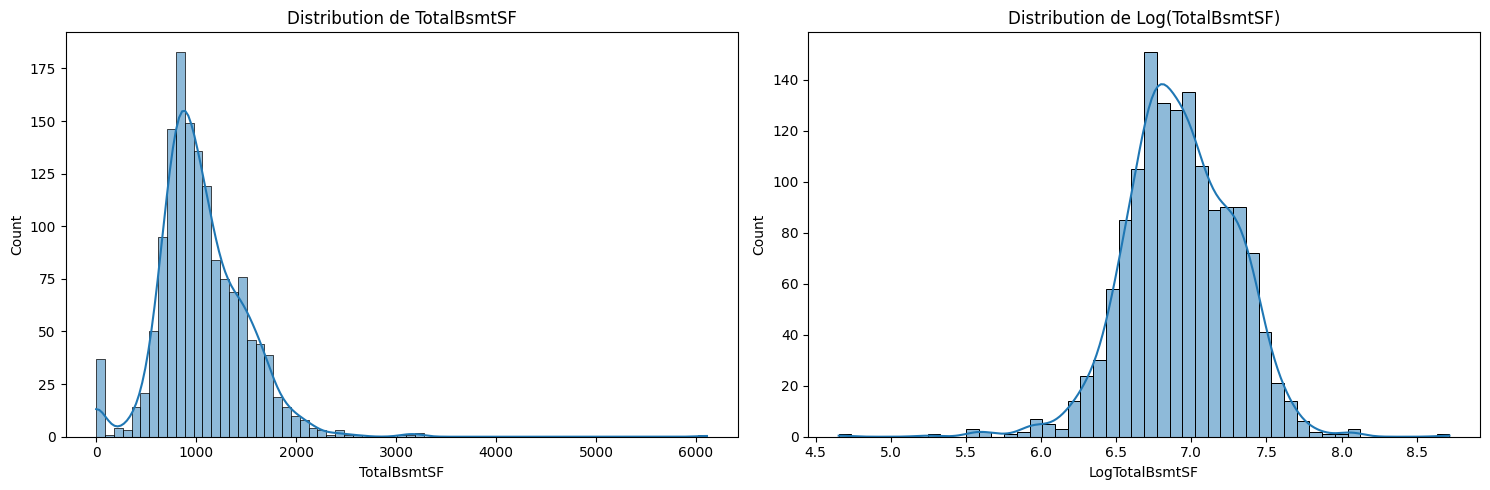

In [98]:
from scipy import stats
train['TotalBsmtSF']
train['LogTotalBsmtSF'] = np.log(train['TotalBsmtSF'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de TotalBsmtSF')
sns.histplot(train['TotalBsmtSF'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(TotalBsmtSF)')
sns.histplot(train['LogTotalBsmtSF'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
shapiro_test = stats.shapiro(train['TotalBsmtSF'])
print(f'Shapiro-Wilk test statistic for TotalBsmtSF: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

In [102]:
shapiro_test = stats.shapiro(train['TotalBsmtSF'])
print(f'Shapiro-Wilk test statistic for TotalBsmtSF: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic for TotalBsmtSF: 0.917, p-value: 1.611e-27


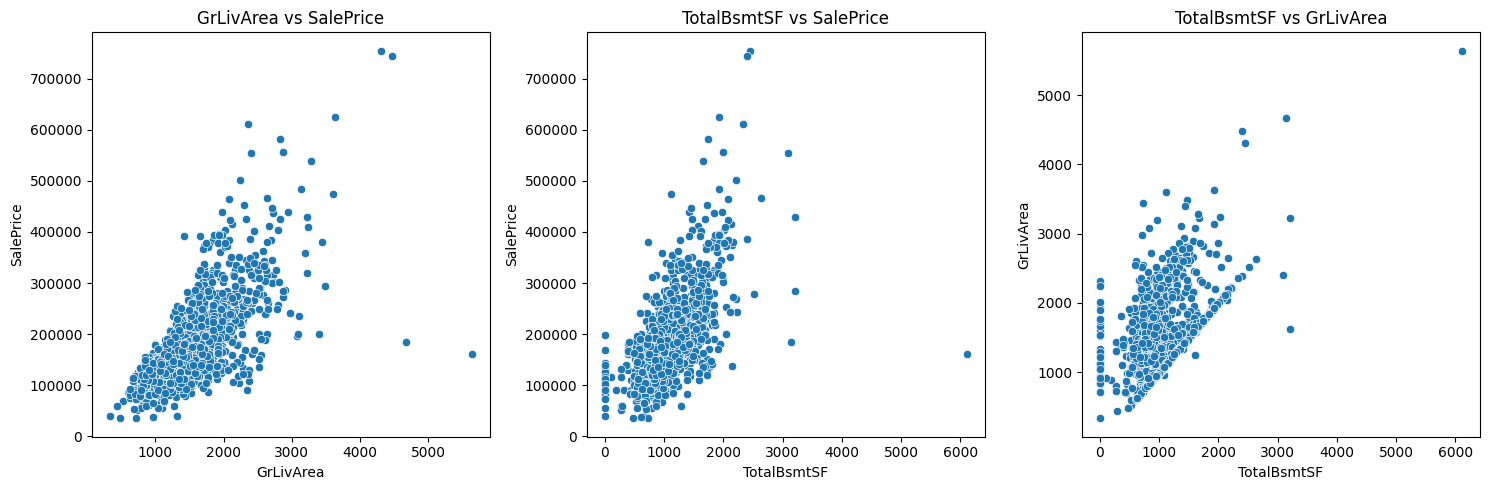

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='GrLivArea', data=train, ax=axes[2])
axes[2].set_title('TotalBsmtSF vs GrLivArea')
plt.tight_layout()

<Axes: xlabel='YearBuilt', ylabel='Count'>

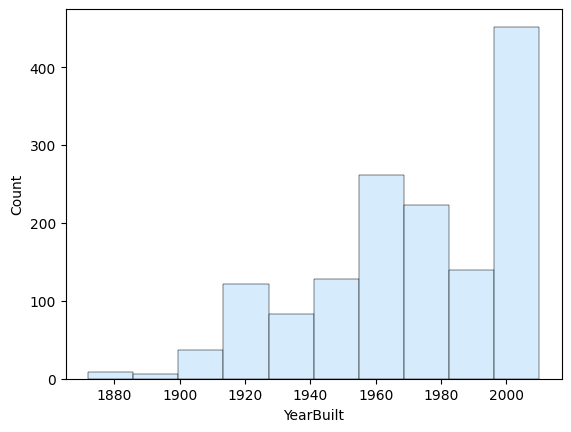

In [104]:
sns.histplot(train['YearBuilt'], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)

<Axes: xlabel='YrSold', ylabel='SalePrice'>

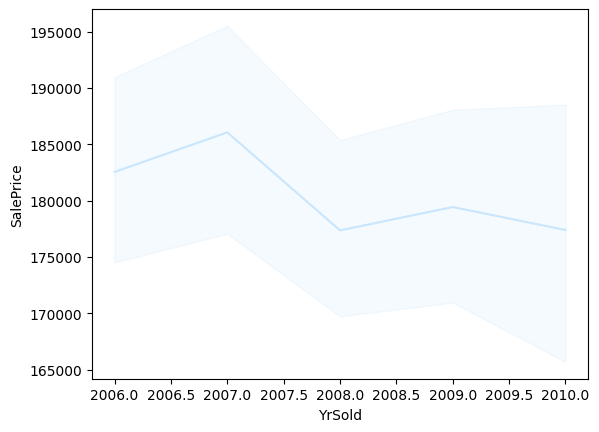

In [125]:
sns.lineplot(train, x= train['YrSold'], y=train['SalePrice'], color='#c9e6fd')

In [127]:
max(train['YrSold'])

2010

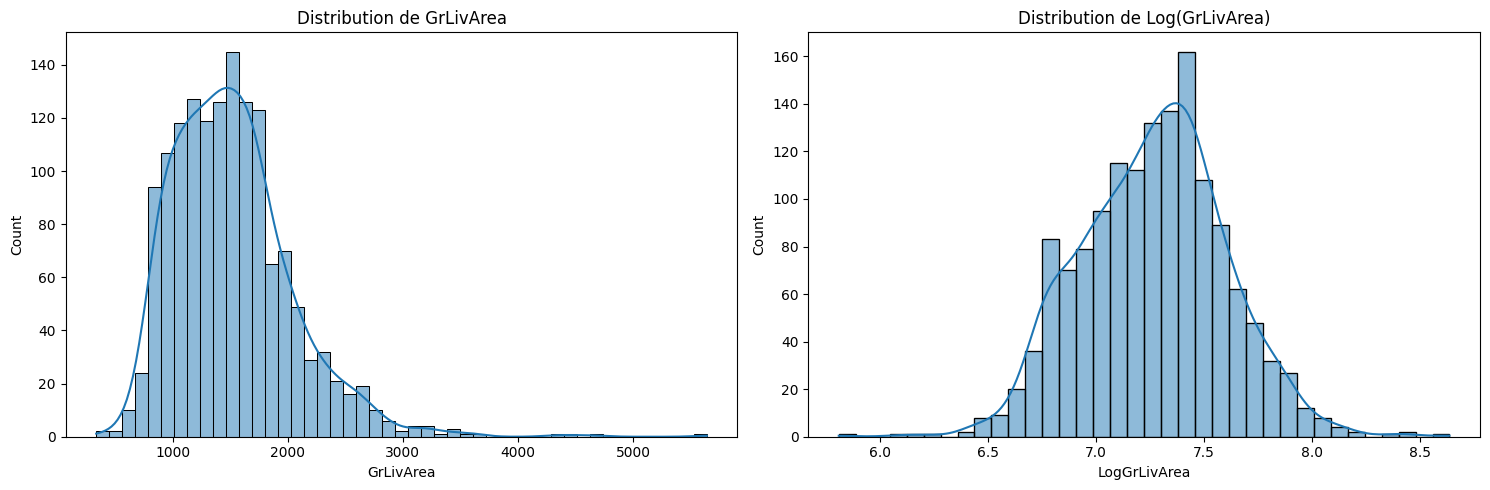

In [105]:
from scipy import stats

train['LogGrLivArea'] = np.log(train['GrLivArea'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de GrLivArea')
sns.histplot(train['GrLivArea'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(GrLivArea)')
sns.histplot(train['LogGrLivArea'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

ANOVA a un facteur

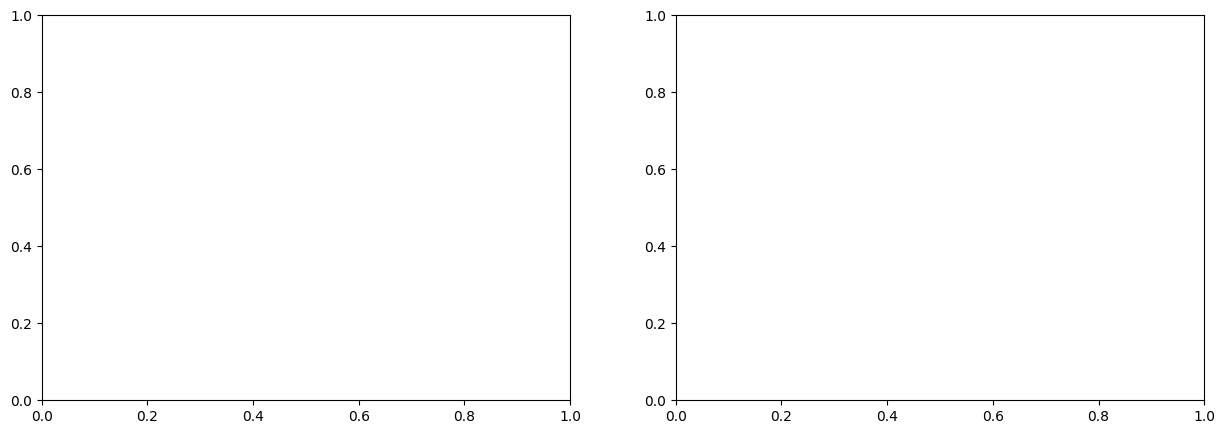

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#sns.barplot(data=train.reset_index(), x='SalePrice', y="LotShape", hue="index", ax=axes[0])
#sns.histplot(data=train.reset_index(), x='SalePrice', y="LotShape", hue="index", ax=axes[1])



In [122]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_anova = train[features + ['LogSalePrice']].copy()
for col in features:
    train_anova[col] = train_anova[col].fillna('None').astype('category')
anova_results = []
for col in features:
    model = ols(f'LogSalePrice ~ C({col})', data=train_anova).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    anova_results.append({'Feature': col, 'p-value': p_value, 'Significant': p_value < 0.05})
df_anova = pd.DataFrame(anova_results)
print(df_anova.sort_values(by='p-value'))


       Feature        p-value  Significant
0  OverallQual   0.000000e+00         True
1    ExterQual  6.935425e-195         True
2     BsmtQual  2.031282e-188         True
3  KitchenQual  4.441486e-187         True
4  FireplaceQu  6.963458e-115         True
5   CentralAir   9.855628e-44         True
6     LotShape   7.856968e-29         True
7    LandSlope   3.388375e-01        False
8       MoSold   4.496616e-01        False
9       YrSold   5.656374e-01        False


/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_1817/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_1817/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_1817/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use 

ANOVA a deux facteurs

In [130]:
features_significatives = df_anova[df_anova['Significant']]['Feature'].tolist()
features_significatives

['OverallQual',
 'ExterQual',
 'BsmtQual',
 'KitchenQual',
 'FireplaceQu',
 'CentralAir',
 'LotShape']

In [131]:
from itertools import combinations

for col1, col2 in combinations(features_significatives, 2):
    formula = f'LogSalePrice ~ C({col1}) * C({col2})'
    interaction_model = ols(formula, data=train_anova).fit()
    interaction_table = sm.stats.anova_lm(interaction_model, typ=2)
    p_value_interaction = interaction_table.iloc[2,3]
    if p_value_interaction < 0.05:
        print(f"\n---Interaction significative entre {col1} et {col2}---")
        print(f"   p-value de l'interaction: {p_value_interaction:.3e}")
        print(interaction_table)



---Interaction significative entre OverallQual et ExterQual---
   p-value de l'interaction: 5.296e-52
                                 sum_sq      df           F         PR(>F)
C(OverallQual)               204.185376     9.0  458.077839  6.178398e-294
C(ExterQual)                   0.218335     3.0    1.469465   2.210927e-01
C(OverallQual):C(ExterQual)   21.397849    27.0   16.001604   5.296425e-52
Residual                      70.922798  1432.0         NaN            NaN

---Interaction significative entre OverallQual et BsmtQual---
   p-value de l'interaction: 4.155e-81
                               sum_sq      df           F         PR(>F)
C(OverallQual)              62.067024     9.0  141.810704  2.684882e-122
C(BsmtQual)                  0.075201     4.0    0.386593   8.183527e-01
C(OverallQual):C(BsmtQual)  37.448082    36.0   21.390339   4.155408e-81
Residual                    69.444460  1428.0         NaN            NaN

---Interaction significative entre OverallQual et Kitc

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 21
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 

In [133]:
pd.crosstab(train['OverallQual'], train['ExterQual'])

ExterQual,2,3,4,5
OverallQual,,,,
1,2,0,0,0
2,1,2,0,0
3,2,16,2,0
4,5,110,1,0
5,2,378,17,0
6,1,297,74,2
7,1,96,218,4
8,0,6,154,8
9,0,1,19,23


Test de Tukey


---Tukey HSD pour OverallQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0 

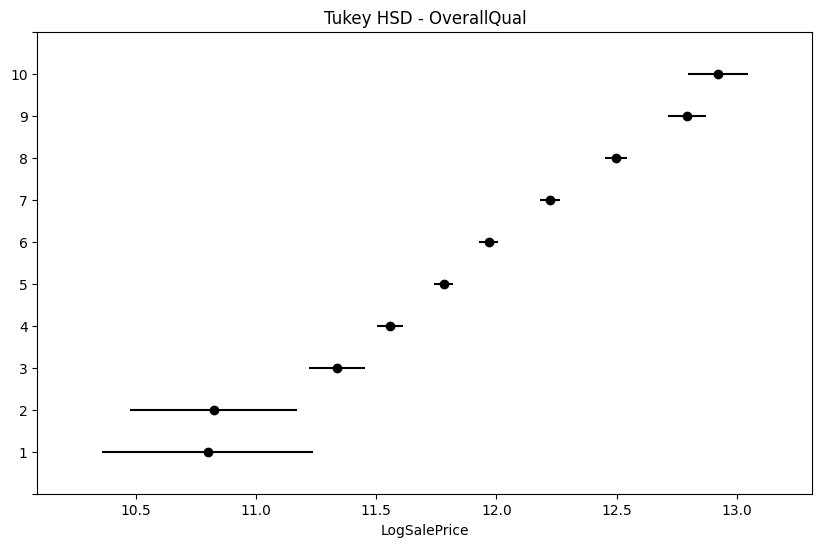


---Tukey HSD pour ExterQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     2      3   0.5334   0.0 0.3301 0.7368   True
     2      4   1.0067   0.0 0.8021 1.2114   True
     2      5   1.4595   0.0 1.2322 1.6868   True
     3      4   0.4733   0.0 0.4309 0.5157   True
     3      5   0.9261   0.0 0.8184 1.0337   True
     4      5   0.4528   0.0 0.3426 0.5629   True
-------------------------------------------------


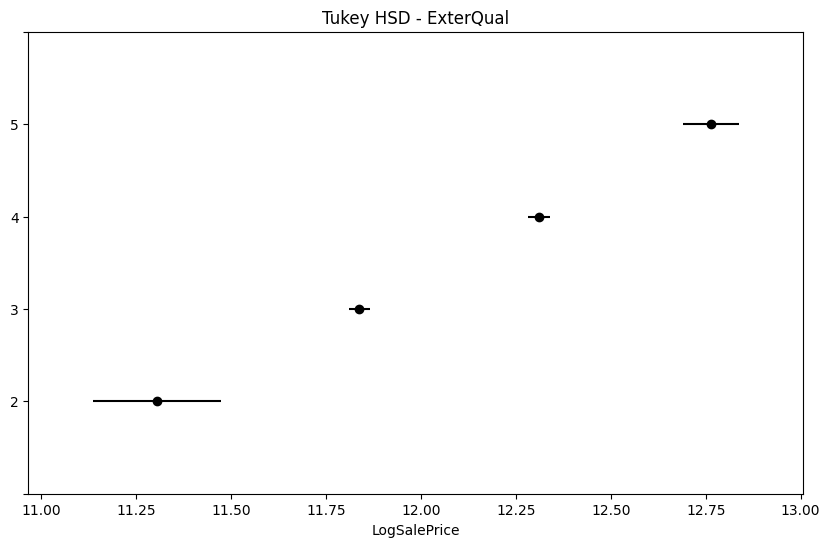


---Tukey HSD pour BsmtQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      2   0.0879 0.7161 -0.1027 0.2786  False
     0      3   0.2812    0.0  0.1445 0.4178   True
     0      4   0.6502    0.0  0.5134  0.787   True
     0      5   1.1107    0.0  0.9588 1.2626   True
     2      3   0.1933 0.0016   0.053 0.3336   True
     2      4   0.5623    0.0  0.4218 0.7028   True
     2      5   1.0228    0.0  0.8676  1.178   True
     3      4    0.369    0.0  0.3236 0.4145   True
     3      5   0.8295    0.0  0.7495 0.9096   True
     4      5   0.4605    0.0  0.3801 0.5409   True
---------------------------------------------------


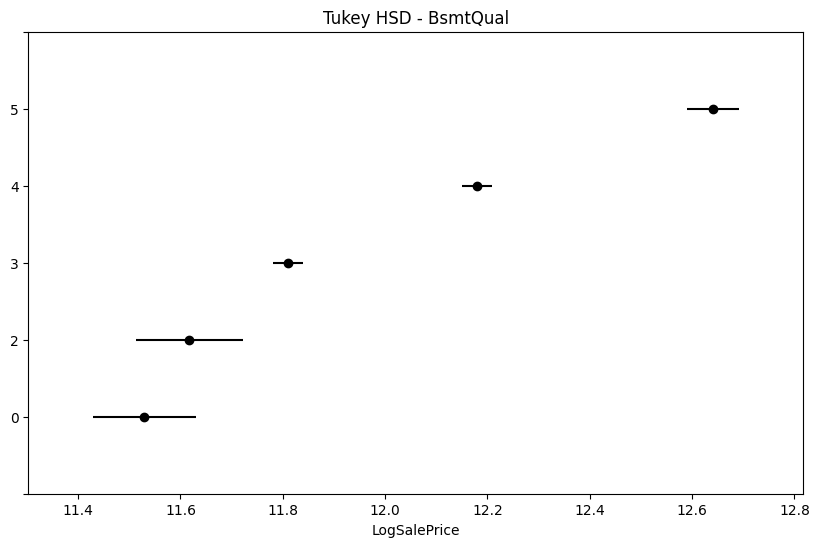


---Tukey HSD pour KitchenQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     2      3    0.306   0.0 0.1804 0.4316   True
     2      4   0.7178   0.0 0.5914 0.8442   True
     2      5    1.129   0.0 0.9847 1.2733   True
     3      4   0.4117   0.0 0.3694 0.4541   True
     3      5    0.823   0.0 0.7416 0.9045   True
     4      5   0.4113   0.0 0.3286  0.494   True
-------------------------------------------------


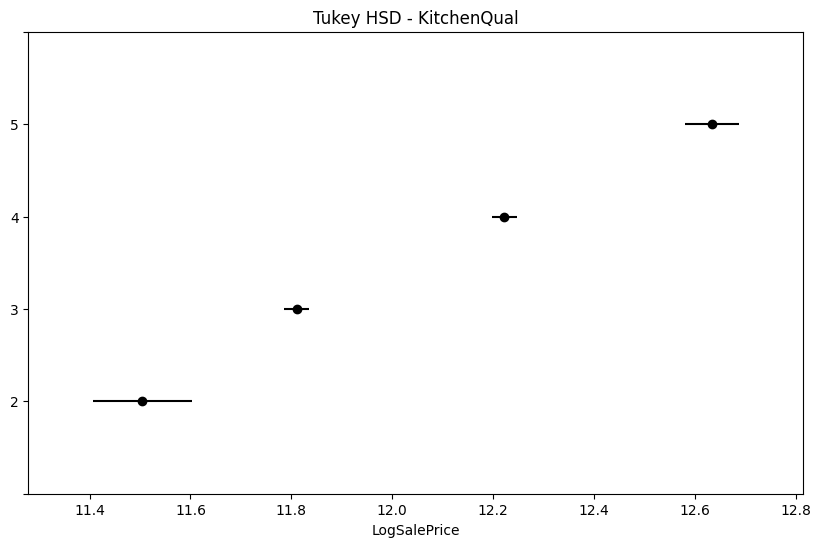


---Tukey HSD pour FireplaceQu---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1  -0.0701 0.9387 -0.2851 0.1449  False
     0      2   0.1996 0.0099  0.0307 0.3685   True
     0      3   0.3775    0.0  0.3129 0.4421   True
     0      4   0.4476    0.0  0.3871 0.5082   True
     0      5   0.8611    0.0  0.6643 1.0579   True
     1      2   0.2697 0.0484  0.0011 0.5383   True
     1      3   0.4476    0.0   0.229 0.6662   True
     1      4   0.5177    0.0  0.3003 0.7352   True
     1      5   0.9312    0.0  0.6442 1.2182   True
     2      3   0.1779 0.0406  0.0044 0.3514   True
     2      4    0.248 0.0006   0.076   0.42   True
     2      5   0.6615    0.0  0.4072 0.9158   True
     3      4   0.0701 0.0637 -0.0022 0.1425  False
     3      5   0.4836    0.0  0.2828 0.6844   True
     4      5   0.4135    0.0   0.214  0.613   True
------------------------------

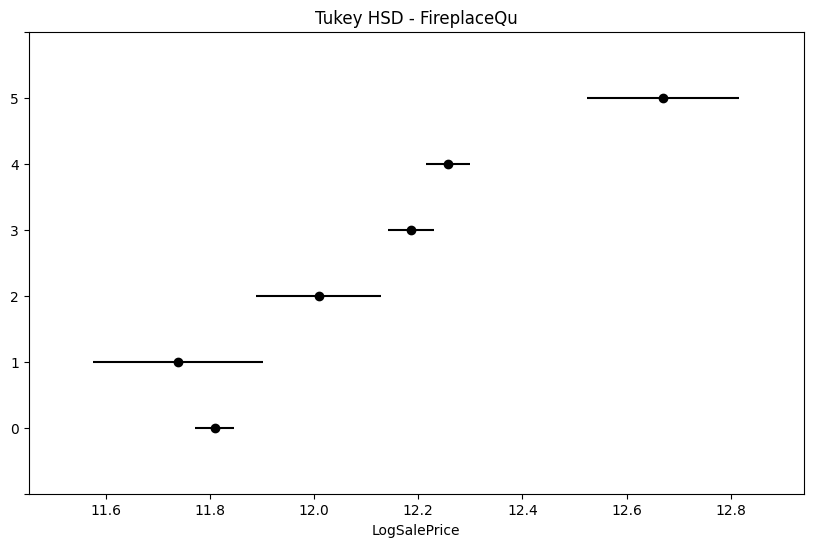


---Tukey HSD pour CentralAir---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     N      Y   0.5692   0.0 0.4914 0.6471   True
-------------------------------------------------


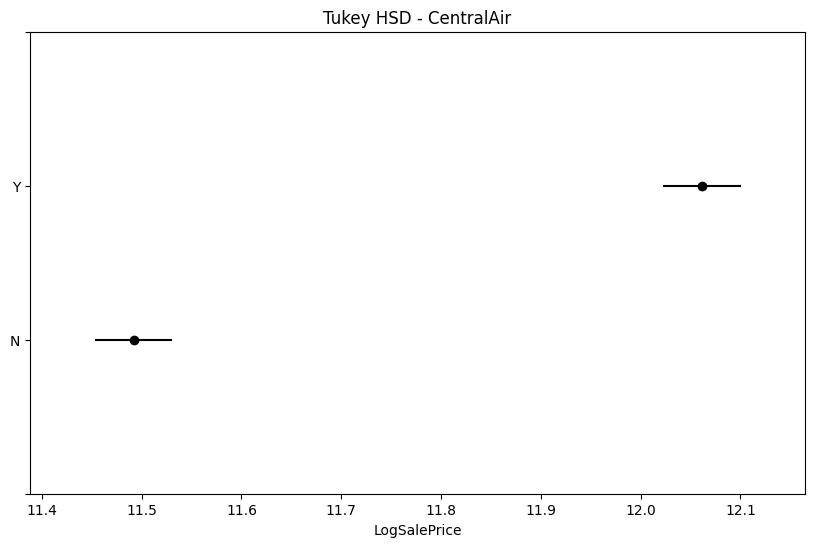


---Tukey HSD pour LotShape---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2    0.113 0.8357 -0.2334  0.4595  False
     1      3  -0.0419  0.986 -0.3558  0.2719  False
     1      4  -0.2693 0.1188 -0.5816   0.043  False
     2      3   -0.155 0.0611 -0.3148  0.0048  False
     2      4  -0.3824    0.0 -0.5391 -0.2256   True
     3      4  -0.2274    0.0 -0.2825 -0.1723   True
----------------------------------------------------


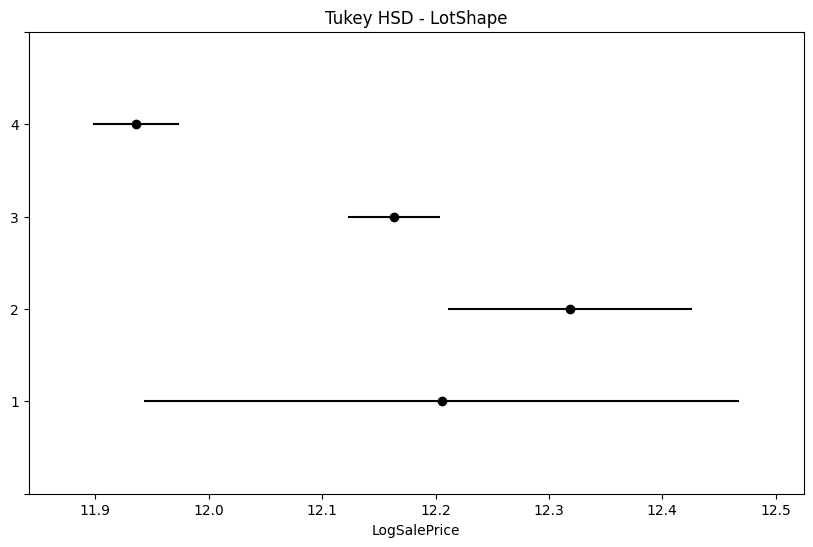


---Tukey HSD pour LandSlope---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2  -0.0537 0.8977 -0.3384  0.231  False
     1      3    -0.11 0.5844 -0.3711 0.1511  False
     2      3  -0.0563 0.5077 -0.1752 0.0626  False
---------------------------------------------------


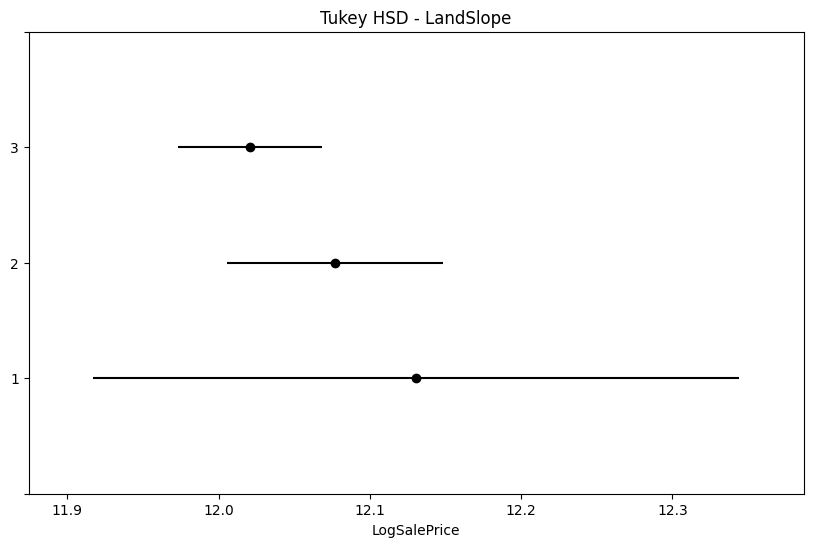


---Tukey HSD pour MoSold---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0838 0.9948  -0.166 0.3335  False
     1      3   0.0668 0.9972 -0.1467 0.2804  False
     1      4   0.0088    1.0 -0.1952 0.2127  False
     1      5   0.0215    1.0  -0.173 0.2161  False
     1      6   0.0566 0.9982 -0.1337  0.247  False
     1      7   0.0795 0.9712 -0.1123 0.2713  False
     1      8   0.0858 0.9728 -0.1228 0.2943  False
     1      9   0.1353 0.7834 -0.1027 0.3732  False
     1     10   0.0568 0.9995 -0.1638 0.2775  False
     1     11   0.1115 0.9038 -0.1146 0.3376  False
     1     12    0.099 0.9738 -0.1428 0.3407  False
     2      3  -0.0169    1.0 -0.2383 0.2045  False
     2      4   -0.075 0.9919 -0.2871 0.1372  False
     2      5  -0.0622 0.9977 -0.2653 0.1409  False
     2      6  -0.0271    1.0 -0.2262  0.172  False
     2      7  -0.0043    1.0 -0.20

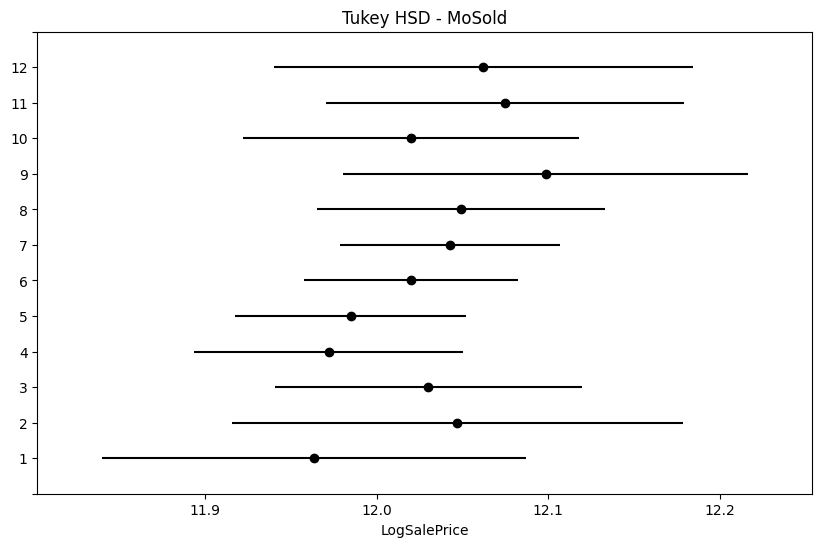


---Tukey HSD pour YrSold---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2006   2007   0.0157 0.9876 -0.0704 0.1018  False
  2006   2008  -0.0208 0.9673 -0.1086  0.067  False
  2006   2009  -0.0262 0.9187 -0.1118 0.0593  False
  2006   2010  -0.0339 0.8971 -0.1369  0.069  False
  2007   2008  -0.0365 0.7814 -0.1233 0.0504  False
  2007   2009  -0.0419 0.6567 -0.1265 0.0426  False
  2007   2010  -0.0496 0.6747 -0.1517 0.0525  False
  2008   2009  -0.0055 0.9998 -0.0917 0.0808  False
  2008   2010  -0.0131 0.9969 -0.1167 0.0904  False
  2009   2010  -0.0077 0.9996 -0.1093  0.094  False
---------------------------------------------------


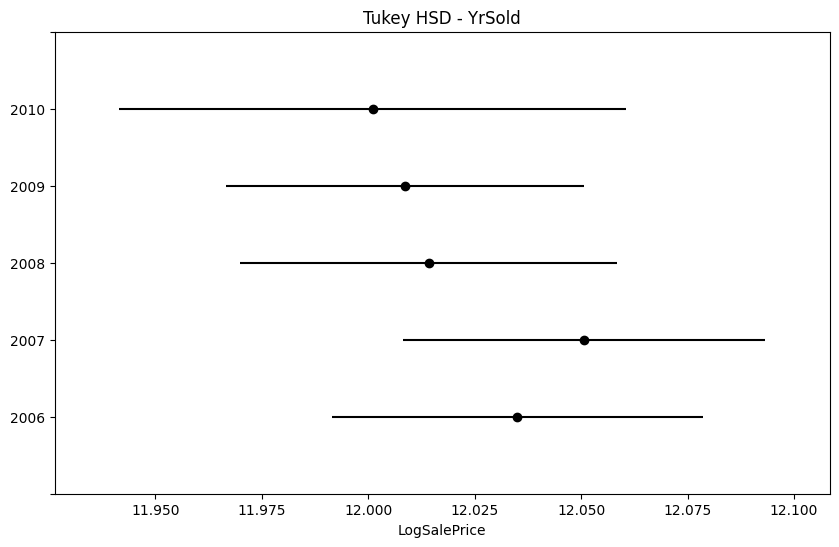

In [124]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for col in features:
    tukey = pairwise_tukeyhsd(endog=train_anova['LogSalePrice'], groups=train_anova[col], alpha=0.05)
    print(f"\n---Tukey HSD pour {col}---")
    print(tukey.summary())
    tukey.plot_simultaneous()
    plt.title(f'Tukey HSD - {col}')
    plt.xlabel('LogSalePrice')
    plt.show()

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [ ]:
#Nous allons retenir les 3 features les plus significatives pour la suite de l'analyse
k = 3
# OverallQual, KitchenQual, CentralAir
df_factoriel = train[['LogSalePrice']].copy()
df_factoriel['A'] = (train['OverallQual'] >= 7).astype(int)
df_factoriel['B'] = train['KitchenQual'].isin(['Ex', 'Gd']).astype(int)
df_factoriel['C'] = (train['CentralAir'] == 'Y').astype(int)
means = df_factoriel.groupby(['A', 'B', 'C'])['LogSalePrice'].mean().reset_index()
print("Table des moyennes par combinaison de facteurs:")
print(means)
                     

Table des moyennes par combinaison de facteurs:
   A  B  C  LogSalePrice
0  0  0  0     11.442358
1  0  0  1     11.807476
2  0  1  0     11.835974
3  0  1  1     11.988174
4  1  0  0     11.808353
5  1  0  1     12.133962
6  1  1  0     12.250226
7  1  1  1     12.412245


In [ ]:
print(df_factoriel['B'])

0       1
1       0
2       1
3       1
4       1
       ..
1455    0
1456    0
1457    1
1458    1
1459    0
Name: B, Length: 1460, dtype: int64


---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.